# 📌 Parameter-Efficient Fine-Tuning (PEFT)

## 🔍 What is PEFT?

**Parameter-Efficient Fine-Tuning (PEFT)** is a method used to adapt large pretrained models—like LLMs (Large Language Models)—to specific downstream tasks by **training only a small subset of parameters**. It allows most of the model to remain unchanged (frozen), which significantly reduces the time, memory, and computational cost required for fine-tuning.

### ✅ Key Characteristics
- Trains only a small number of additional parameters.
- Keeps the core pretrained model unchanged.
- Enhances adaptability for new tasks with fewer resources.

---

## ⚙️ How Does PEFT Work?

PEFT operates by:

1. **Freezing** the majority of the pretrained model’s parameters.
2. **Injecting small trainable modules** (e.g., adapters) or vectors (e.g., prompts, prefixes) into specific layers.
3. Fine-tuning only these added components for a given downstream task.

💡 **Example**: In a transformer model, adapters might be added between layers or in residual connections, and only these are updated during training.

🔧 PEFT is often combined with **gradient checkpointing** for additional memory efficiency.

---

## 🎯 Why is PEFT Important?

PEFT provides an optimal balance between **efficiency** and **performance** by:

- Reducing the need to retrain or store large models.
- Enabling fine-tuning of LLMs like GPT-3, LLaMA, and BERT with fewer resources.
- Avoiding catastrophic forgetting and reducing the risk of overfitting.
- Making LLMs more **accessible** to smaller teams and **flexible** for specialized tasks.

---

## 🔄 PEFT vs Traditional Fine-Tuning

| Feature                      | Traditional Fine-Tuning                | Parameter-Efficient Fine-Tuning (PEFT)     |
|-----------------------------|----------------------------------------|--------------------------------------------|
| Parameter Updates           | All parameters                        | Only a small subset                        |
| Memory/Storage Usage        | High                                  | Low                                        |
| Catastrophic Forgetting     | Likely                                 | Unlikely                                   |
| Overfitting Risk            | Higher                                | Lower                                      |
| Training Speed              | Slower                                | Faster                                     |
| Accessibility               | Costly, resource-heavy                | Cost-effective, widely accessible          |

---

## 🌟 Benefits of PEFT

### 🧠 Increased Efficiency
- Saves GPU usage and cloud costs.
- Requires fewer compute resources.

### ⏱ Faster Time-to-Value
- Less time needed for training and deployment.
- Faster iteration cycles for downstream tasks.

### 🧩 No Catastrophic Forgetting
- Retains pretrained knowledge while specializing.

### 🔒 Lower Risk of Overfitting
- Frozen weights act as regularization.
- Improved generalization on small data.

### 📉 Lower Data Requirements
- Can work with much smaller datasets.
- Effective in low-resource and few-shot settings.

### 💸 More Accessible AI
- Democratizes LLM usage for smaller orgs and researchers.

### 🧪 More Flexible AI
- Supports experimentation and quick adaptation.

---

## 🧪 PEFT Techniques

### 🔌 1. **Adapters**
- Introduced early in NLP applications.
- Small neural modules inserted in each layer.
- Only adapter weights are trainable.
- Great for **multi-task learning** and **transfer learning**.

### ➗ 2. **LoRA (Low-Rank Adaptation)**
- Decomposes weight updates into low-rank matrices.
- Greatly reduces trainable parameters.
- Widely adopted due to simplicity and effectiveness.

### 🧮 3. **QLoRA (Quantized LoRA)**
- Builds on LoRA but **quantizes weights to 4-bits**.
- Enables fine-tuning large models on a **single GPU**.
- Offers **massive memory savings** without much accuracy loss.

### 📎 4. **Prefix-Tuning**
- Appends a **trainable prefix vector** to each attention layer.
- Base model parameters are **frozen**.
- Designed for **natural language generation (NLG)** tasks.
- Stores thousands of times fewer parameters than full fine-tuning.

### 💬 5. **Prompt-Tuning**
- Adds trainable **soft prompts** to input sequences.
- **Hard prompts**: Manually designed text prompts.
- **Soft prompts**: Learnable embedding vectors.
- Effective for instruction tuning and text classification.

### 🧠 6. **P-Tuning**
- Extends prompt-tuning with **automated prompt generation**.
- Tailored for **natural language understanding (NLU)**.
- Learns prompts dynamically for better task performance.

---

## 📚 Summary

Parameter-Efficient Fine-Tuning (PEFT) is a powerful, flexible, and resource-conscious method for adapting large models to specific downstream tasks. By fine-tuning only select parameters—via methods like LoRA, Adapters, and Prompt-Tuning—it achieves strong performance with:

- ✅ Lower computational cost
- ✅ Faster deployment
- ✅ Better generalization
- ✅ Broader accessibility

🛠 Whether you're deploying LLMs for chatbots, classification, summarization, or domain-specific applications—**PEFT enables you to do more with less**.

---

## 📦 Resources

- 🤗 [Hugging Face PEFT Library](https://huggingface.co/docs/peft)
- 📄 [LoRA Paper](https://arxiv.org/abs/2106.09685)
- 📄 [QLoRA Paper](https://arxiv.org/abs/2305.14314)


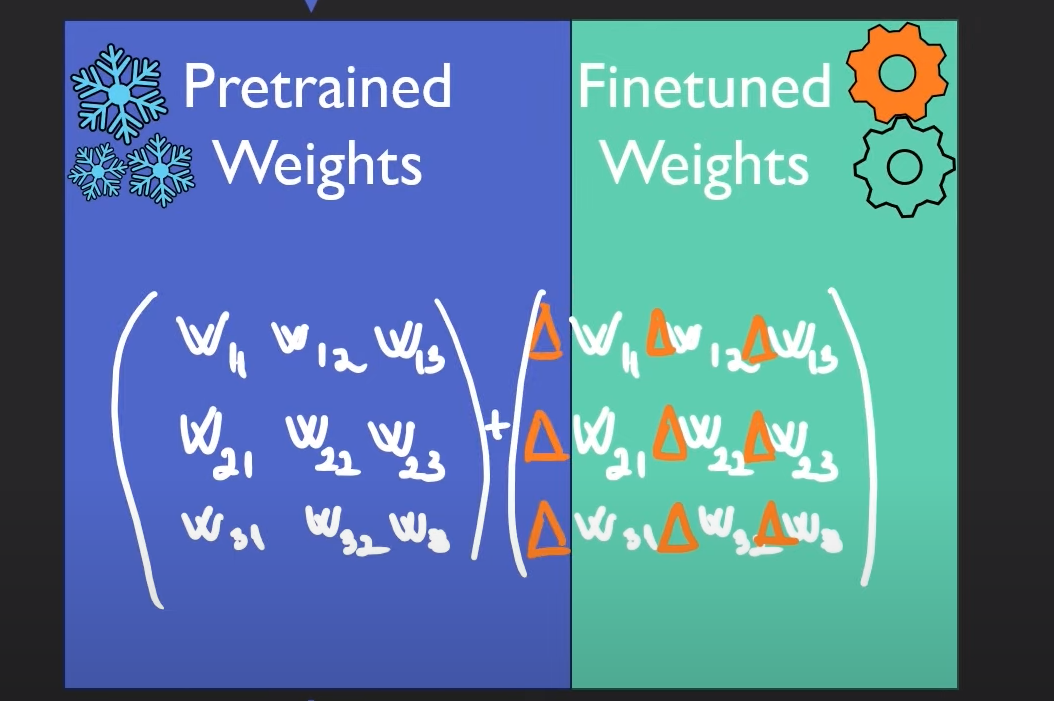

# Understanding LoRA — Low Rank Adaptation For Finetuning Large Models

Fine-tuning large pre-trained models is computationally challenging, often involving adjustment of millions of parameters. This traditional fine-tuning approach, while effective, demands substantial computational resources and time, posing a bottleneck for adapting these models to specific tasks. LoRA presented an effective solution to this problem by decomposing the update matrix during finetuing. To study LoRA, let us start by first revisiting traditional finetuing.

### Decomposition of ( Δ W )
In traditional fine-tuning, we modify a pre-trained neural network’s weights to adapt to a new task. This adjustment involves altering the original weight matrix ( W ) of the network. The changes made to ( W ) during fine-tuning are collectively represented by ( Δ W ), such that the updated weights can be expressed as ( W + Δ W ).

Now, rather than modifying ( W ) directly, the LoRA approach seeks to decompose ( Δ W ). This decomposition is a crucial step in reducing the computational overhead associated with fine-tuning large models.

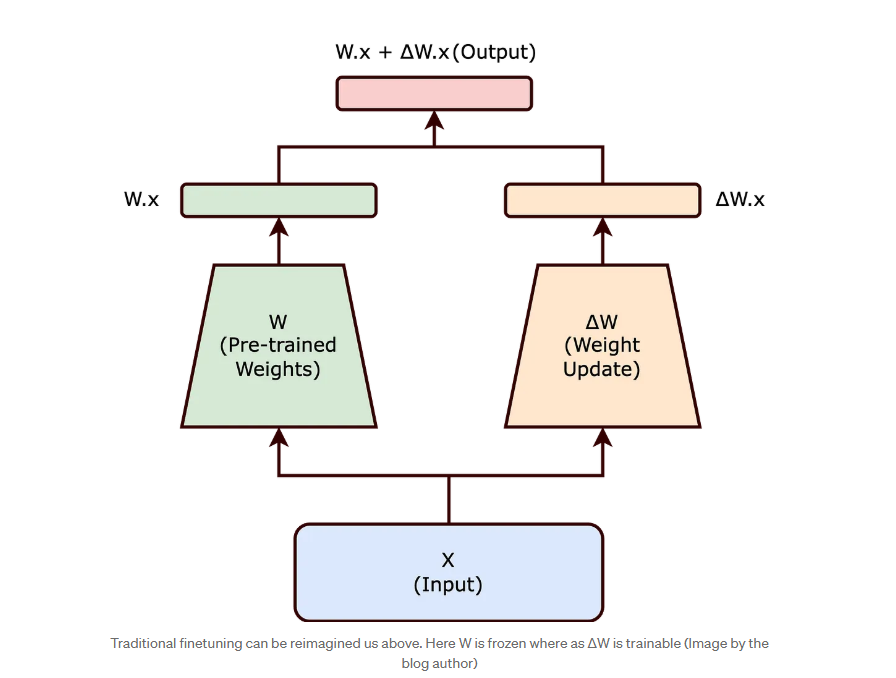

### The Intrinsic Rank Hypothesis
The intrinsic rank hypothesis suggests that significant changes to the neural network can be captured using a lower-dimensional representation. Essentially, it posits that not all elements of ( Δ W ) are equally important; instead, a smaller subset of these changes can effectively encapsulate the necessary adjustments.

### Introducing Matrices ( A ) and ( B )
Building on this hypothesis, LoRA proposes representing ( Δ W ) as the product of two smaller matrices, ( A ) and ( B ), with a lower rank. The updated weight matrix ( W’ ) thus becomes:

[ W’ = W + BA ]

In this equation, ( W ) remains frozen (i.e., it is not updated during training). The matrices ( B ) and ( A ) are of lower dimensionality, with their product ( BA ) representing a low-rank approximation of ( Δ W ).



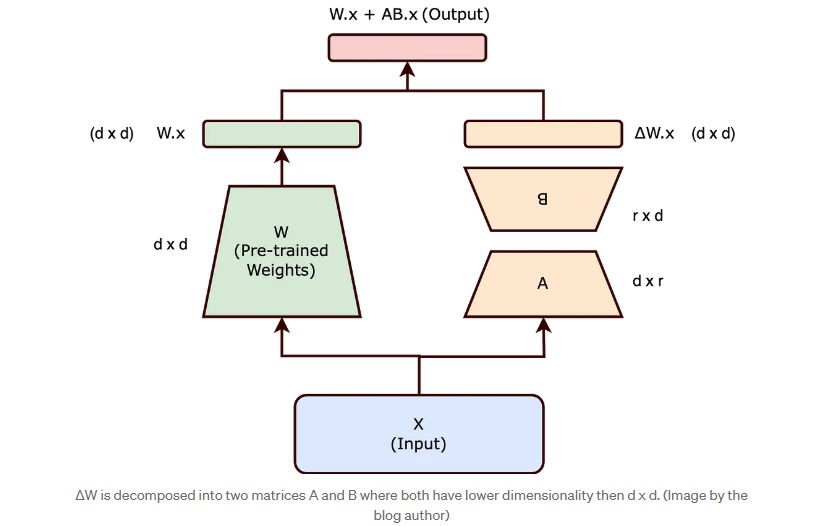

## **Impact of Lower Rank on Trainable Parameters**
By choosing matrices ( A ) and ( B ) to have a lower rank ( r ), the number of trainable parameters is significantly reduced. For example, if ( W ) is a ( d x d ) matrix, traditionally, updating ( W ) would involve ( d² ) parameters. However, with ( B ) and ( A ) of sizes ( d x r ) and ( r x d ) respectively, the total number of parameters reduces to ( 2dr ), which is much smaller when ( r << d ).

The reduction in the number of trainable parameters, as achieved through the Low-Rank Adaptation (LoRA) method, offers several significant benefits, particularly when fine-tuning large-scale neural networks:

- Reduced Memory Footprint: LoRA decreases memory needs by lowering the number of parameters to update, aiding in the management of large-scale models.
- Faster Training and Adaptation: By simplifying computational demands, LoRA accelerates the training and fine-tuning of large models for new tasks.
- Feasibility for Smaller Hardware: LoRA’s lower parameter count enables the fine-tuning of substantial models on less powerful hardware, like modest GPUs or CPUs.
- Scaling to Larger Models: LoRA facilitates the expansion of AI models without a corresponding increase in computational resources, making the management of growing model sizes more practical.


In the context of LoRA, the concept of rank plays a pivotal role in determining the efficiency and effectiveness of the adaptation process. Remarkably, the paper highlights that the rank of the matrices A and B can be astonishingly low, sometimes as low as one.

Although the LoRA paper predominantly showcases experiments within the realm of Natural Language Processing (NLP), the underlying approach of low-rank adaptation holds broad applicability and could be effectively employed in training various types of neural networks across different domains.

### Conclusion
LoRA’s approach to decomposing ( Δ W ) into a product of lower rank matrices effectively balances the need to adapt large pre-trained models to new tasks while maintaining computational efficiency. The intrinsic rank concept is key to this balance, ensuring that the essence of the model’s learning capability is preserved with significantly fewer parameters.

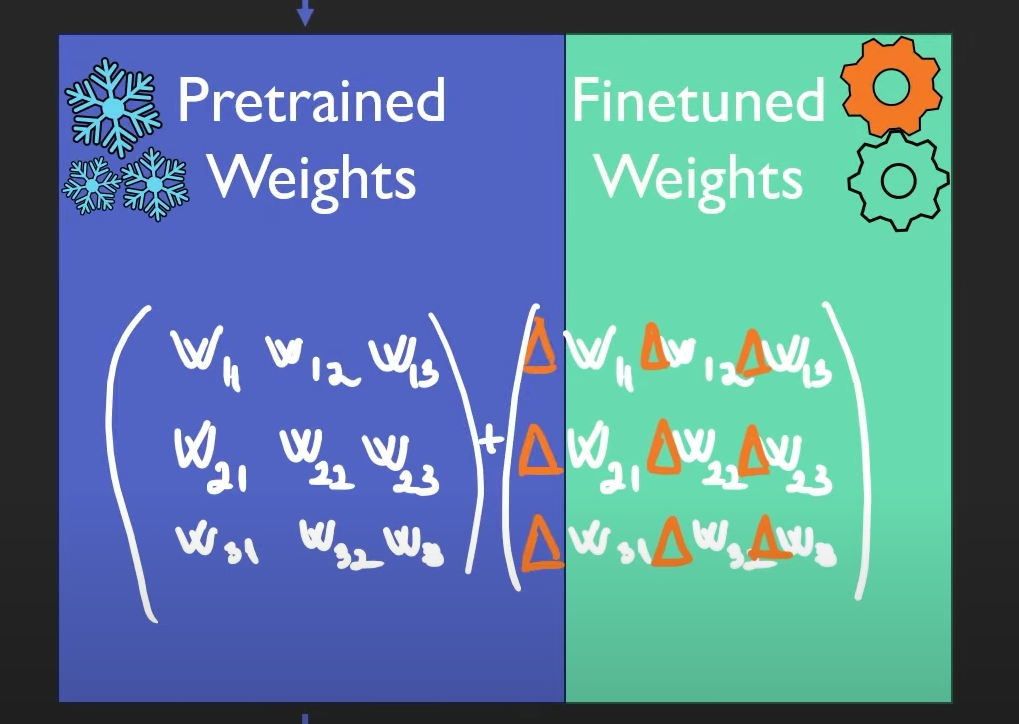

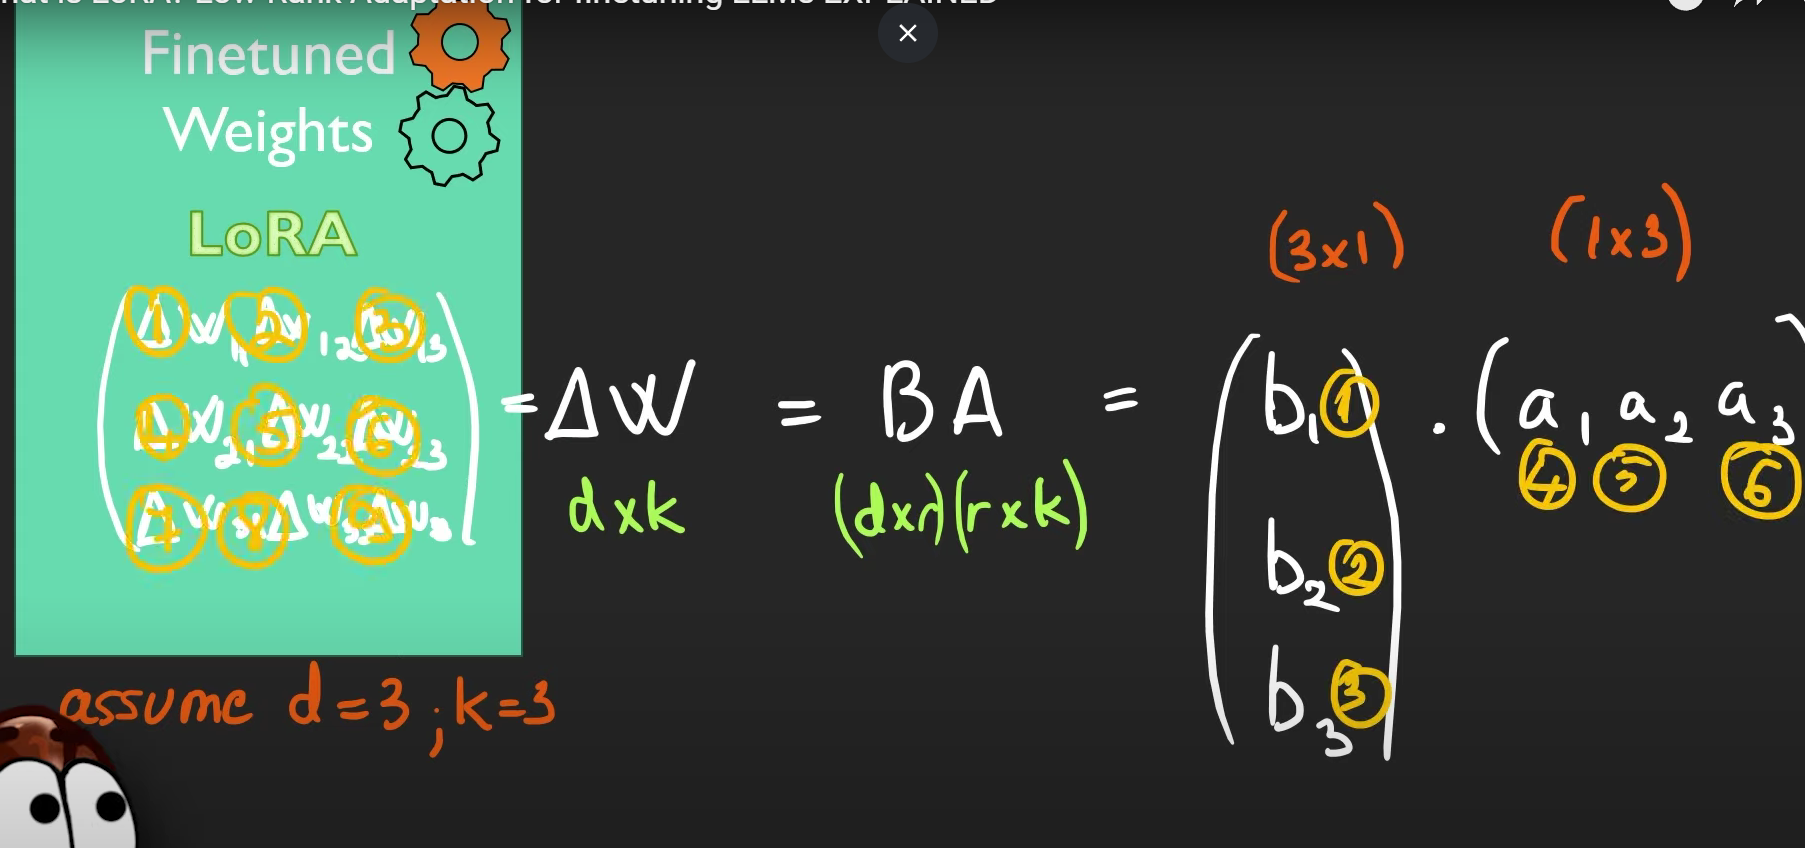

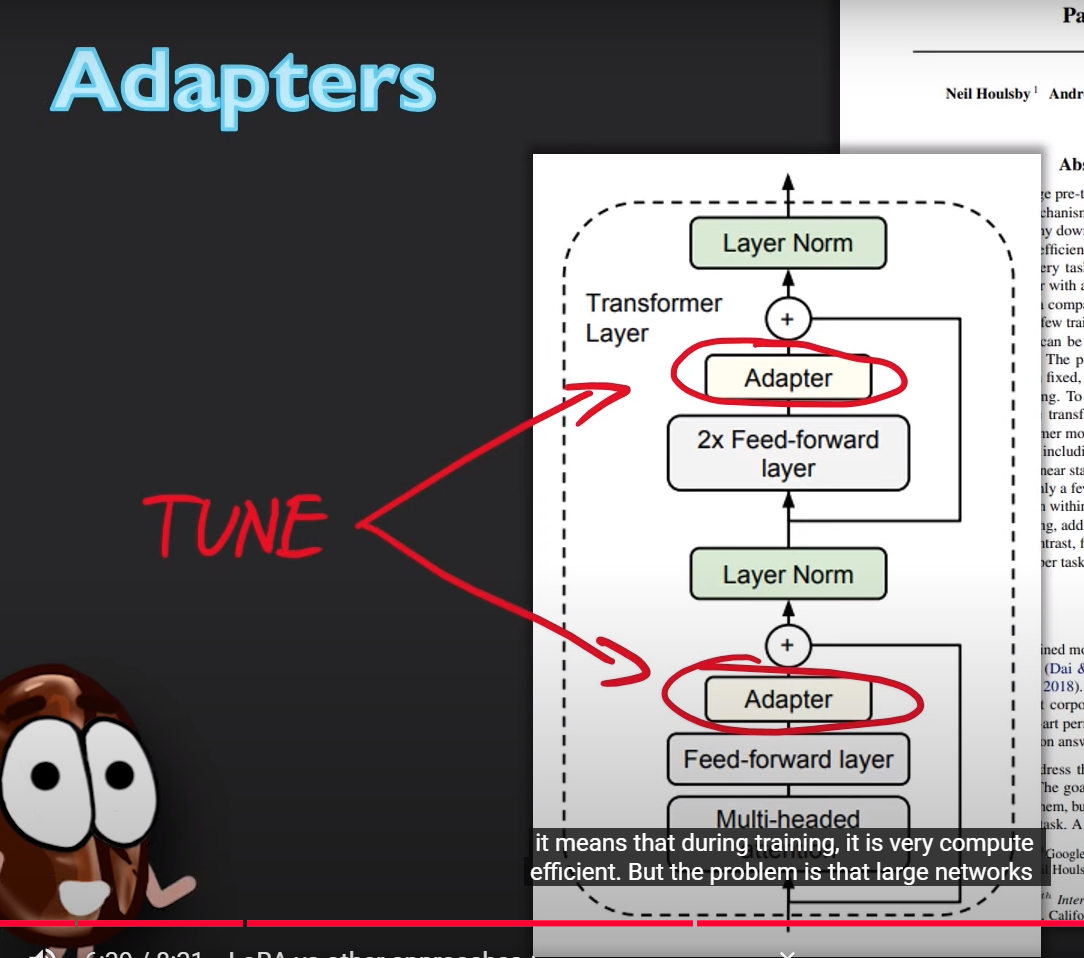

# ⚙️ QLoRA (Quantized Low-Rank Adaptation)

## 🔍 What is QLoRA?

**QLoRA** stands for **Quantized Low-Rank Adaptation**. It is a **parameter-efficient fine-tuning (PEFT)** technique designed to fine-tune **very large language models (LLMs)** using limited computational resources—**even on a single GPU**. 

QLoRA builds upon **LoRA (Low-Rank Adaptation)** by introducing **quantization** to the pretrained model’s weights, reducing memory consumption dramatically while maintaining or even improving performance.

---

## 🎯 Why QLoRA?

Training or fine-tuning large LLMs is expensive and often inaccessible to individuals or small organizations. QLoRA solves this by:

- Reducing memory requirements
- Supporting massive models on low-resource hardware
- Maintaining performance parity with full-precision fine-tuning

---

## ⚙️ How Does QLoRA Work?

QLoRA combines three core ideas:

### 1. **4-bit Quantization of Model Weights**
- The pretrained model weights are **quantized to 4-bit precision** using **NF4 (NormalFloat4)** or **FP4** formats.
- These quantized weights are **frozen** during training (not updated).
- Memory footprint is **drastically reduced**, enabling fine-tuning of models like LLaMA-65B on a single 48GB GPU.

### 2. **LoRA (Low-Rank Adaptation)**
- Instead of updating full weight matrices, **low-rank matrices** are added and trained.
- These **LoRA adapters** are small in size and efficient to train.
- The model learns task-specific knowledge through these adapters.

### 3. **Paged Optimizers and Efficient Memory Management**
- QLoRA uses a **paged optimizer** to manage memory more effectively during training.
- This ensures memory stability and efficient GPU utilization.

---

## 🔢 Components of QLoRA

| Component           | Description |
|--------------------|-------------|
| **NF4 Quantization** | A 4-bit quantization format that preserves distribution properties of float32. |
| **LoRA Adapter**     | Two trainable low-rank matrices injected into each layer’s weight matrices. |
| **Frozen Weights**   | All original model weights are frozen, saving compute and memory. |
| **Paged Optimizer**  | Dynamically loads optimizer states into memory in a paged fashion. |

---

## 📈 Advantages of QLoRA

### 💾 Memory Efficient
- Can fine-tune **65B parameter models on a single GPU** (e.g., A100 with 48GB VRAM).
- Uses **only ~1/20th** the memory compared to full-precision models.

### ⚡ Fast and Scalable
- Training is faster due to fewer parameters being updated.
- Suitable for **low-resource or cloud-constrained environments**.

### 🎯 High Accuracy
- Retains or surpasses the accuracy of full-precision fine-tuning in many benchmarks.

### 🔧 Open and Flexible
- Integrated with frameworks like Hugging Face `transformers`, `peft`, and `bitsandbytes`.
- Can be used for tasks such as text classification, summarization, generation, and more.

---

## 🧪 QLoRA vs LoRA

| Feature              | LoRA                        | QLoRA                               |
|----------------------|-----------------------------|-------------------------------------|
| Quantization         | ❌ No                        | ✅ Yes (4-bit)                      |
| Memory Savings       | Moderate                    | High                                |
| GPU Requirement      | Multi-GPU / High VRAM       | Single GPU (even consumer-grade)    |
| Accuracy             | High                        | Comparable or better                |
| Use Case             | Efficient tuning            | Ultra-efficient tuning of very large models |

---

## 🛠️ How to Use QLoRA (Example with Hugging Face)

```python
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import torch

# Load 4-bit quantized model
model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    load_in_4bit=True,
    device_map="auto"
)

# Prepare model for k-bit training
model = prepare_model_for_kbit_training(model)

# Define LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Apply PEFT with LoRA
model = get_peft_model(model, lora_config)

# Now, the model is ready for training on your downstream task
```

---

## 📚 QLoRA in Research

- **Paper**: *QLoRA: Efficient Finetuning of Quantized LLMs* (Dettmers et al., 2023)  
  🔗 [https://arxiv.org/abs/2305.14314](https://arxiv.org/abs/2305.14314)

### 🧪 Key Results from the Paper:
- Fine-tuned 65B LLaMA model on a **single 48GB GPU**
- Achieved **state-of-the-art results** on multiple benchmarks (e.g., AlpacaEval, MT-Bench)
- Introduced **NF4**, a novel quantization format for high-accuracy low-bit LLMs

---

## 🧠 Use Cases of QLoRA

- Domain-specific LLM adaptation
- Low-cost chatbots or assistants
- Specialized summarization and classification tasks
- Edge deployment of LLMs
- Fine-tuning in academia or startups with limited compute

---

## 🔚 Conclusion

**QLoRA** represents a major step in making LLMs accessible, scalable, and efficient. By combining **quantization** and **low-rank adaptation**, it unlocks the ability to **fine-tune billion-parameter models using minimal resources**—without sacrificing performance.

> 🧠 *Train large, serve small: QLoRA makes it practical.*

---

## 🔗 Resources

- 📘 [QLoRA Research Paper](https://arxiv.org/abs/2305.14314)
- 🤗 [Hugging Face PEFT Library](https://huggingface.co/docs/peft/index)
- 🧮 [BitsAndBytes for 4-bit Training](https://github.com/TimDettmers/bitsandbytes)
- 💬 [Hugging Face QLoRA Tutorial](https://huggingface.co/blog/qlora)


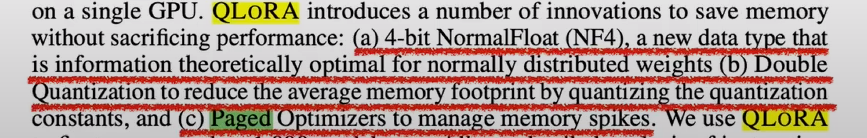

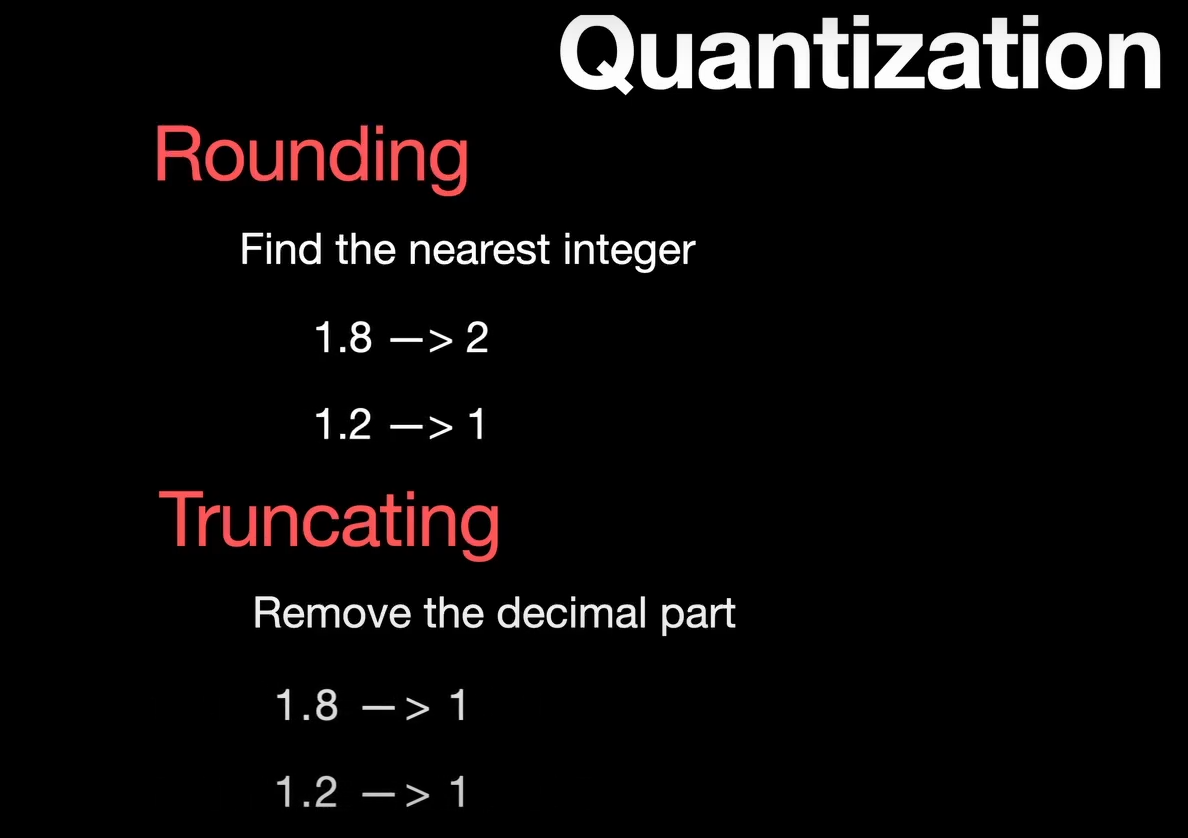

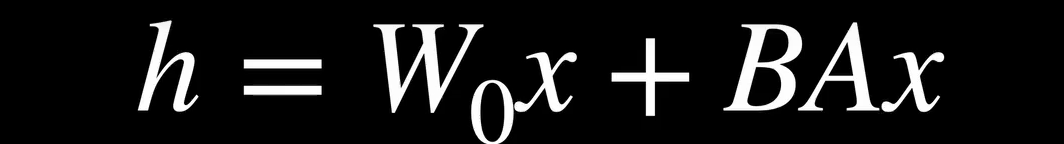

# 🤖 Reinforcement Learning-Based Fine-Tuning for LLMs: PPO, GRPO, and DPO

---

## 1. 🧠 PPO: Proximal Policy Optimization

### 🔍 What is PPO?

**PPO (Proximal Policy Optimization)** is a reinforcement learning algorithm used to fine-tune language models (like GPT) with human feedback. It strikes a balance between **improving model behavior** and **preventing drastic updates** that could destabilize the model.

Originally developed by OpenAI, PPO is at the heart of **RLHF (Reinforcement Learning with Human Feedback)**.

---

### ⚙️ How PPO Works

1. **Pretrained LLM** generates candidate outputs (actions) for a given prompt.
2. A **reward model** (trained using human preferences) scores those outputs.
3. PPO uses **policy gradient** updates to fine-tune the model based on those rewards.
4. A **KL penalty** prevents the updated model from drifting too far from the original policy.

---

### 🧪 Example

Suppose a model generates two responses to a user query:
- Response A: “Sure! I can help with that.”
- Response B: “Yeah, whatever.”

Humans prefer Response A. The reward model gives:
- A: +1
- B: -1

PPO will fine-tune the model to favor responses like A while staying close to the original model’s behavior using a KL-divergence constraint.

---

### ✅ Advantages

- Improves response quality with human-aligned rewards
- Keeps updates stable via clipped objectives

---

## 2. 🔁 GRPO: Generalized Rejection Sampling Policy Optimization

### 🔍 What is GRPO?

**GRPO** is a more **general and stable version** of PPO. It addresses theoretical and empirical flaws in PPO by introducing a cleaner connection between **rejection sampling** and **policy learning**.

While PPO uses approximate gradients with clipping, **GRPO provides a better approximation** to the optimal reward-maximizing policy using **statistical reweighting**.

---

### 🧠 Key Idea

Instead of using a surrogate loss and clipping like PPO, **GRPO builds a new policy by reweighting the base policy** according to the reward:
```
π*(y|x) ∝ π₀(y|x) × exp(R(y)/β)
```
Where:
- `π₀` is the base policy (pretrained model),
- `R(y)` is the reward for output `y`,
- `β` is a temperature parameter controlling exploration.

---

### 🧪 Example

Prompt: “What is 2 + 2?”

Candidate outputs:
- A: “4” → reward: +2
- B: “5” → reward: -1

GRPO adjusts the policy to prefer A by assigning it exponentially more probability without the need for KL clipping, using:
```
P(A) ∝ P₀(A) × exp(2/β)
P(B) ∝ P₀(B) × exp(-1/β)
```

---

### ✅ Advantages

- More accurate gradient estimation than PPO
- Simpler theoretical formulation
- Better alignment between reward model and policy

---

## 3. 💡 DPO: Direct Preference Optimization

### 🔍 What is DPO?

**DPO (Direct Preference Optimization)** is a **non-reinforcement learning** alternative to PPO. Instead of estimating rewards and optimizing with policy gradients, DPO **directly optimizes model preferences** based on pairwise human feedback.

It is simpler, more stable, and requires no reward model.

---

### ⚙️ How DPO Works

1. Human annotators or a preference dataset provide **chosen vs rejected** outputs.
2. DPO adjusts the model to **increase the probability of the preferred response** and **decrease it for the rejected one**.
3. The optimization objective is derived from **inverse reinforcement learning**.

---

### 📘 DPO Objective

For a prompt `x` with two responses `y⁺` (preferred) and `y⁻` (rejected), DPO maximizes:
```
L_DPO ∝ log σ(β × [log π(y⁺|x) - log π(y⁻|x)])
```
Where:
- `σ` is the sigmoid function
- `β` is a temperature parameter
- `π` is the model’s policy

This encourages the model to increase the log-probability of the better response.

---

### 🧪 Example

Prompt: “Explain Newton’s third law.”

Two completions:
- A: “Every action has an equal and opposite reaction.” ✅ (preferred)
- B: “It talks about gravity pulling us down.” ❌

DPO directly tunes the model so that the log-likelihood of A becomes higher than B.

---

### ✅ Advantages

- No need to train a reward model
- No KL penalty tuning
- Simpler to implement
- Competitive performance with PPO and RLHF

---

## 🧮 Comparison Table

| Feature        | PPO                         | GRPO                         | DPO                          |
|----------------|------------------------------|-------------------------------|-------------------------------|
| Type           | Reinforcement Learning       | Sampling-Based RL             | Preference-Based Supervised   |
| Reward Model   | ✅ Required                  | ✅ Required                   | ❌ Not Needed                 |
| KL Penalty     | ✅ Required                  | ❌ (implicit via sampling)     | ✅ Optional (if used)         |
| Gradient Type  | Approximate via Clipping     | Reweighting-Based             | Exact from Preference Pairs   |
| Simplicity     | ❌ Complex                   | ⚠️ Moderate                   | ✅ Simple                     |
| Performance    | ✅ High                      | ✅ High                        | ✅ High                       |

---

## 🏁 Conclusion

| Algorithm | Best For |
|----------|-----------|
| **PPO**  | Full RLHF pipelines with reward models |
| **GRPO** | Theoretically sound and more stable PPO alternative |
| **DPO**  | Simple, scalable preference learning without RL |

Each technique aligns LLMs with human preferences using different philosophies:
- **PPO** = Reward learning + policy gradient
- **GRPO** = Probabilistic reweighting
- **DPO** = Direct preference learning

---

## 🔗 Further Reading

- 📝 PPO: [Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- 🧪 GRPO: [Generalized Rejection Sampling](https://arxiv.org/abs/2305.17023)
- 📘 DPO: [Direct Preference Optimization](https://arxiv.org/abs/2305.18290)
